In [2]:
pip install -U sentence-transformers==5.1.0 -q

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install --upgrade sentence-transformers -q


Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import glob
import numpy as np
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import torch
import sys
import os
import matplotlib.pyplot as plt
import transformers
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn.functional as F

print(transformers.__version__)

4.57.6


In [15]:
# Leer archivo parquet
chunks_df = pd.read_parquet(r"/kaggle/input/datasets/karengomezmontoya/chunks/chunks.parquet")
# Ver columnas
print("Columnas disponibles:", chunks_df.columns)

Columnas disponibles: Index(['id_doc', 'autor_doc', 'fecha_doc', 'diario_doc', 'titulo_doc',
       'chunk_id', 'texto_chunk'],
      dtype='object')


In [16]:
len(chunks_df)

62651

In [20]:
# Leer excel diccionario literatura normalizado
obras_df = pd.read_excel(r"/kaggle/input/datasets/karengomezmontoya/diccionarios-literatura/diccionarios_literatura_sin_tildes.xlsx")
print(obras_df.columns)

Index(['instance_primary_contributor', 'contributors', 'extraido', 'title',
       'notes', 'publication_site', 'publisher', 'dateOfPublication',
       'pais_origen', 'fuente', 'title_author'],
      dtype='object')


In [21]:
len(obras_df)

45415

In [17]:
# Login into Hugging Face Hub 
# Crear cuenta en hugging face.co y obtener token de acceso para subir modelos
from huggingface_hub import login
login()


In [18]:

# model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "google/embeddinggemma-300M"
model = SentenceTransformer(model_id).to(device = device)

print(f"Device: {model.device}")
print(model)
print("Total number of parameters in the model:", sum([p.numel() for _, p in model.named_parameters()]))

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

Device: cuda:0
SentenceTransformer(
  (0): Transformer({'max_seq_length': 2048, 'do_lower_case': False, 'architecture': 'Gemma3TextModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Dense({'in_features': 768, 'out_features': 3072, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity'})
  (3): Dense({'in_features': 3072, 'out_features': 768, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity'})
  (4): Normalize()
)
Total number of parameters in the model: 307581696


In [19]:
print(model.max_seq_length)

2048


In [30]:
# PARTE 1: Crear embeddings por obra y autor

def obtener_embeddings_obras(
    obras_df,
    model,
    col="title_author",
    batch_size=128,
    save_path="/kaggle/working/obras_embeddings.npy",
    RELOAD=False
):
    if not RELOAD and os.path.exists(save_path):
        print(f"Embeddings encontrados en {save_path}, cargando...")
        embeddings = np.load(save_path)
        print(f"Embeddings cargados con forma: {embeddings.shape}")
        return embeddings
        
    print("Calculando embeddings desde cero...")
    textos = obras_df[col].tolist()
    embeddings = model.encode(
        textos,
        batch_size=batch_size,
        convert_to_tensor=True,
        show_progress_bar=True,
        prompt="task: search result | query: "
    )

    embeddings_np = embeddings.cpu().numpy()

    # Crear carpeta si no existe
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Guardar embeddings
    np.save(save_path, embeddings_np)
    print(f"Embeddings calculados y guardados en {save_path}")

    return embeddings_np


# PARTE 2: Calcular embeddings chunks

def obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=64,
    save_path="/kaggle/working/chunk_embeddings.npy",
    RELOAD=False
):
    """
    Calcula o carga embeddings de los chunks según el valor de RELOAD.
    
    Args:
        chunks_df (pd.DataFrame): DataFrame con columna 'texto_chunk'
        model: modelo de sentence-transformers
        batch_size (int): tamaño del lote para encoding
        save_path (str): ruta donde guardar/cargar embeddings
        RELOAD (bool): si True, recalcula embeddings aunque exista archivo
    
    Returns:
        np.ndarray con embeddings de los chunks
    """
    
    if not RELOAD and os.path.exists(save_path):
        print(f"Embeddings encontrados en {save_path}, cargando...")
        embeddings = np.load(save_path)
        print(f"Embeddings cargados con forma: {embeddings.shape}")
        return embeddings
    
    print("Calculando embeddings desde cero...")
    textos = chunks_df["texto_chunk"].tolist()
    chunk_embeddings = model.encode(
        textos,
        batch_size=batch_size,
        convert_to_tensor=True,
        show_progress_bar=True,
        prompt="title: none | text: "
    )

    embeddings_np = chunk_embeddings.cpu().numpy()

    # Crear carpeta si no existe
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Guardar embeddings
    np.save(save_path, embeddings_np)
    print(f"Embeddings calculados y guardados en {save_path}")

    return embeddings_np

def buscar_obras_en_chunks(
    chunks_df,
    obras_df,
    chunk_embeddings,
    obras_embeddings,
    col_obra="title_author",
    similarity_threshold=0.75,
    batch_size=512,          # cuántos chunks procesar a la vez (para no explotar memoria)
    n_chunks=None,           # None = todos; ponés 100 para probar
):
    """
    Para cada chunk, encuentra si alguna obra supera el umbral de similaridad.
    Evita construir la matriz completa 45k x 65k procesando por batches.
    
    Returns:
        pd.DataFrame con columnas: obra_encontrada, id_doc, chunk_id, texto_chunk, similarity_score
    """
    
    # Convertir a tensores en GPU para aprovechar CUDA
    obras_tensor = torch.tensor(obras_embeddings, dtype=torch.float32).to(device)
    obras_tensor = F.normalize(obras_tensor, dim=1)  # normalizar para cosine similarity
    
    # Limitar chunks si se pasa n_chunks
    if n_chunks is not None:
        chunks_subset = chunks_df.iloc[:n_chunks].reset_index(drop=True)
        chunk_embs_subset = chunk_embeddings[:n_chunks]
    else:
        chunks_subset = chunks_df.reset_index(drop=True)
        chunk_embs_subset = chunk_embeddings
    
    resultados = []
    total_chunks = len(chunks_subset)
    
    print(f"Procesando {total_chunks} chunks contra {len(obras_df)} obras...")
    print(f"Threshold de similaridad: {similarity_threshold}")
    
    for i in range(0, total_chunks, batch_size):
        batch_embs = chunk_embeddings[i : i + batch_size]
        batch_df   = chunks_subset.iloc[i : i + batch_size]
        
        # Tensor del batch y normalizar
        batch_tensor = torch.tensor(batch_embs, dtype=torch.float32).to(device)
        batch_tensor = F.normalize(batch_tensor, dim=1)
        
        # Similaridad: (batch_size x dim) @ (dim x n_obras) → (batch_size x n_obras)
        sim_matrix = torch.mm(batch_tensor, obras_tensor.T)  # shape: (batch, 45k)
        

        mask = sim_matrix >= similarity_threshold  # shape: (batch, 45k) → booleano
        chunk_indices_match, obra_indices_match = torch.where(mask)
        scores_match = sim_matrix[chunk_indices_match, obra_indices_match]
        
        if mask.sum() == 0:
            if (i // batch_size) % 10 == 0:
                print(f"  Batch {i//batch_size} | chunks {i}-{i+batch_size} | sin matches")
            continue
        
        # Extraer los que pasan el corte
        chunk_indices_match = chunk_indices_match.cpu().numpy()
        obra_indices_match  = obra_indices_match.cpu().numpy()
        scores_match        = scores_match.cpu().numpy()
        
        for j, obra_idx, score in zip(chunk_indices_match, obra_indices_match, scores_match):
            row = batch_df.iloc[j]
            resultados.append({
                "obra_encontrada":  obras_df.iloc[obra_idx][col_obra],
                "id_doc":           row["id_doc"],
                "chunk_id":         row["chunk_id"],
                "texto_chunk":      row["texto_chunk"],
                "similarity_score": round(float(score), 4),
            })
        
        if (i // batch_size) % 10 == 0:
            print(f"  Batch {i//batch_size} | chunks {i}-{min(i+batch_size, total_chunks)} | matches acumulados: {len(resultados)}")
    
    resultados_df = pd.DataFrame(resultados)
    print(f"\nTotal de matches encontrados: {len(resultados_df)}")
    return resultados_df

# Cálculo de similitudes
Búsqueda

In [28]:
# ── PRUEBA con los primeros 100 chunks ──────────────────────────────────────

import time

# Calculá embeddings (o cargalos si ya existen)
obras_embeddings  = obtener_embeddings_obras(obras_df, model=model, RELOAD=False)
chunk_embeddings  = obtener_embeddings_chunks(chunks_df, model=model, RELOAD=False)



Calculando embeddings desde cero...


Batches:   0%|          | 0/355 [00:00<?, ?it/s]

Embeddings calculados y guardados en /kaggle/working/obras_embeddings.npy
Calculando embeddings desde cero...


Batches:   0%|          | 0/979 [00:00<?, ?it/s]

Embeddings calculados y guardados en /kaggle/working/chunk_embeddings.npy


In [43]:
# Calcular similaridades
start = time.time()

resultados_obras = buscar_obras_en_chunks(
    chunks_df         = chunks_df,
    obras_df          = obras_df,
    chunk_embeddings  = chunk_embeddings,
    obras_embeddings  = obras_embeddings,
    similarity_threshold = 0.55,   # ajustá este valor según resultados
    batch_size        = 512,
    n_chunks          = None,       # ← sólo 100 para estimar tiempo
)

elapsed = time.time() - start

print(f"\nTiempo: {elapsed:.1f}s")


resultados_obras.head(20)

Procesando 62651 chunks contra 45415 obras...
Threshold de similaridad: 0.55
  Batch 0 | chunks 0-512 | matches acumulados: 14
  Batch 10 | chunks 5120-5632 | matches acumulados: 96
  Batch 20 | chunks 10240-10752 | matches acumulados: 145
  Batch 30 | chunks 15360-15872 | matches acumulados: 257
  Batch 40 | chunks 20480-20992 | matches acumulados: 304
  Batch 50 | chunks 25600-26112 | matches acumulados: 396
  Batch 60 | chunks 30720-31232 | matches acumulados: 487
  Batch 70 | chunks 35840-36352 | matches acumulados: 589
  Batch 80 | chunks 40960-41472 | matches acumulados: 640
  Batch 90 | chunks 46080-46592 | sin matches
  Batch 100 | chunks 51200-51712 | matches acumulados: 757
  Batch 110 | chunks 56320-56832 | sin matches
  Batch 120 | chunks 61440-61952 | matches acumulados: 905

Total de matches encontrados: 906

Tiempo: 2.0s


,obra_encontrada,id_doc,chunk_id,texto_chunk,similarity_score
0,Antologia de la poesia colombiana | Rogelio Ec...,9,0,El año viejo se llevó a un gran poeta quien a ...,0.6892
1,El transeunte | Rogelio Echavarria,9,0,El año viejo se llevó a un gran poeta quien a ...,0.5708
2,Antologia de la poesia colombiana | Rogelio Ec...,9,0,El año viejo se llevó a un gran poeta quien a ...,0.6892
3,Lira De Amor : cien poetas colombianos que can...,9,0,El año viejo se llevó a un gran poeta quien a ...,0.5791
4,El transeunte | Rogelio Echavarria,9,0,El año viejo se llevó a un gran poeta quien a ...,0.5708
5,El transeunte | Rogelio Echavarria,9,0,El año viejo se llevó a un gran poeta quien a ...,0.5708
6,El transeunte | Rogelio Echavarria,9,0,El año viejo se llevó a un gran poeta quien a ...,0.5708
7,Versos memorables : las 100 mas famosas poesia...,9,0,El año viejo se llevó a un gran poeta quien a ...,0.6053
8,El transeunte | Rogelio Echavarria,9,0,El año viejo se llevó a un gran poeta quien a ...,0.5708
9,Camas y famas : las mas raras y genuinas histo...,33,0,El que diga Uribe; cualquier cosa que escriba ...,0.6536


In [44]:
resultados_obras.to_excel('/kaggle/working/resultados_busqueda_obras_semantica.xlsx', index=False, sheet_name='Results')


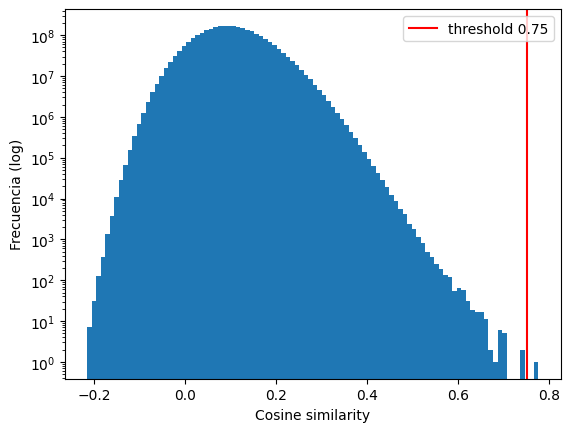

% de pares sobre 0.70: 0.00%
% de pares sobre 0.75: 0.00%
% de pares sobre 0.80: 0.00%


In [42]:
# Para explorar el threshold ideal
sim_sample = torch.mm(
    F.normalize(torch.tensor(chunk_embeddings, dtype=torch.float32).to(device), dim=1),
    F.normalize(torch.tensor(obras_embeddings, dtype=torch.float32).to(device), dim=1).T
)
scores_flat = sim_sample.flatten().cpu().numpy()

import matplotlib.pyplot as plt
plt.hist(scores_flat, bins=100, log=True)
plt.axvline(0.75, color='red', label='threshold 0.75')
plt.xlabel("Cosine similarity")
plt.ylabel("Frecuencia (log)")
plt.legend()
plt.show()

print(f"% de pares sobre 0.70: {(scores_flat > 0.70).mean()*100:.2f}%")
print(f"% de pares sobre 0.75: {(scores_flat > 0.75).mean()*100:.2f}%")
print(f"% de pares sobre 0.80: {(scores_flat > 0.80).mean()*100:.2f}%")